Je recree un notebook car je ne sais pas dans quel fichier devrait etre ce code

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py

In [27]:
def show_transition(filename, state, T_c = 0):

    # Charger les données depuis le fichier HDF5
    filename = f'../data/metropolis/{state}/transition/' + filename

    with h5py.File(filename, 'r') as f:
        # Charger les métadonnées
        J = f['/metadata'].attrs['J']
        B = f['/metadata'].attrs['B']
        T_start = f['/metadata'].attrs['T_start']
        T_end = f['/metadata'].attrs['T_end']
        nb_inter_T = f['/metadata'].attrs['nb_inter_T']
        nb_metropolis_iteration = f['/metadata'].attrs['nb_metropolis_iteration']
        n = f['/metadata'].attrs['n']
        
        # Charger les données C_T
        C_T = f['/C_T'][:]

    # Créer le vecteur de températures
    temperatures = np.linspace(T_start, T_end, nb_inter_T)

    print(f"Données chargées:")
    print(f"  Grille: {n}x{n}")
    if J != 0 or B != 0:
        print(f"  J = {J}, B = {B}")
    print(f"  Températures: {T_start} à {T_end}")
    print(f"  Itérations Metropolis: {nb_metropolis_iteration}")
    print(f"  Nombre de points C_T: {len(C_T)}")

    # Trouver la température de transition (maximum de C_T) pour T > 0.25K
    # Calculer l'index de départ correspondant à T = 0.25
    T_min = 1
    start_idx = int((T_min - T_start) / (T_end - T_start) * nb_inter_T)
    start_idx = max(0, start_idx)  # S'assurer que l'index est >= 0
    
    # Trouver le max dans le sous-tableau et ajouter l'offset
    max_idx = start_idx + np.argmax(C_T[start_idx:])
    T_transition = temperatures[max_idx]
    C_T_max = C_T[max_idx]

    print(f"\nTempérature de transition: T_c ≈ {T_transition:.4f} K")
    print(f"Valeur maximale de C_T: {C_T_max:.4e}")

    # Tracer C_T en fonction de la température
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.scatter(temperatures, C_T, s=0.3, label='Données')
    ax.set_xlabel('Température T (K)', fontsize=12)
    ax.set_ylabel(r'Capacité thermique $C_T$', fontsize=12)
    ax.set_title(f'Transition de phase - Modèle d\'Ising {n}x{n}', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')


    # Tracer la temperature de transition
    if T_c != 0:
        T_transition = T_c
    ax.axvline(T_transition, color='red', label=f'Température de Transition : {T_transition:.3f} K')

    plt.tight_layout()
    plt.legend()
    plt.savefig(f'../figures/metropolis/{state}/transition/{n}.png')
    plt.show()

Données chargées:
  Grille: 3x3
  J = 1.0, B = 0.0
  Températures: 0.001 à 15.0
  Itérations Metropolis: 50000
  Nombre de points C_T: 20000

Température de transition: T_c ≈ 2.2015 K
Valeur maximale de C_T: 2.0893e+00


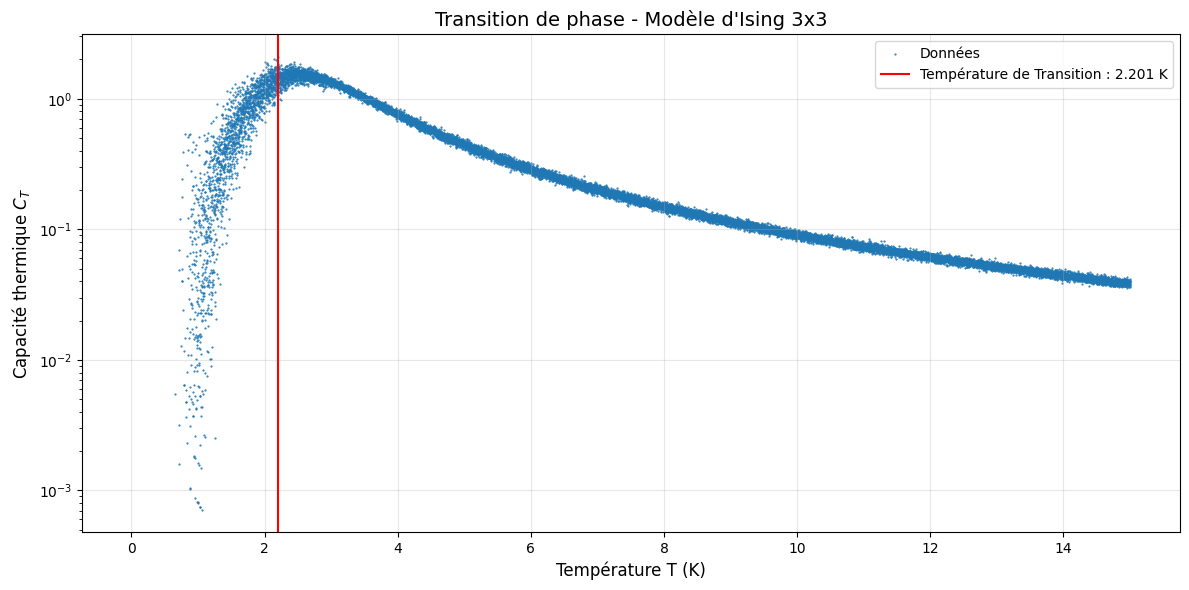

Données chargées:
  Grille: 10x10
  J = 1.0, B = 0.0
  Températures: 0.001 à 15.0
  Itérations Metropolis: 50000
  Nombre de points C_T: 20000

Température de transition: T_c ≈ 2.3057 K
Valeur maximale de C_T: 1.8852e+02


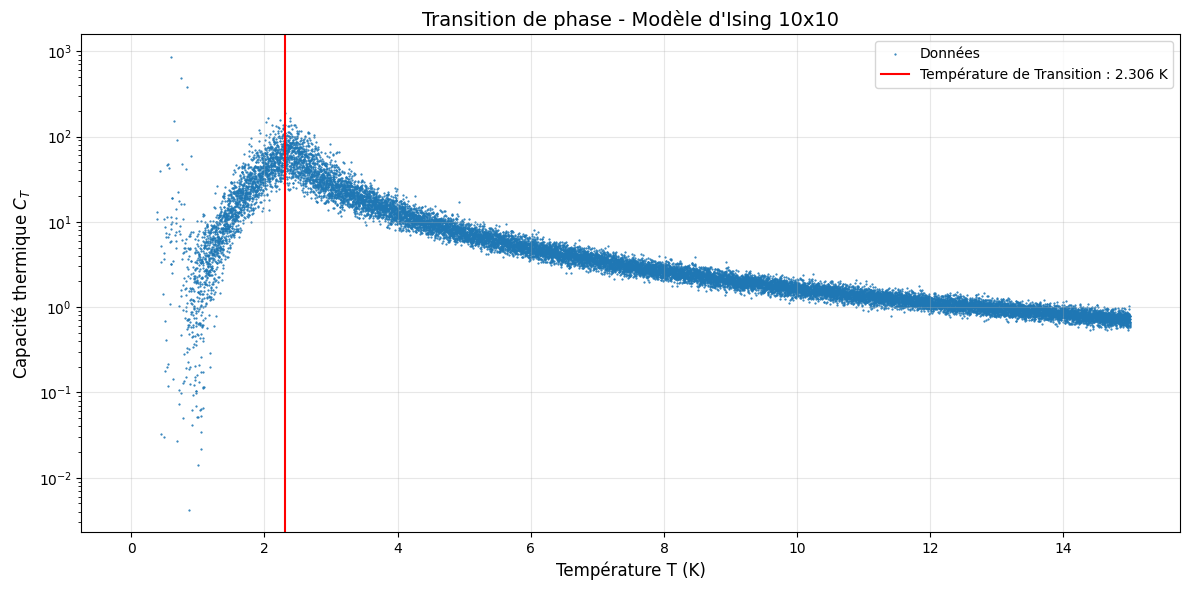

Données chargées:
  Grille: 30x30
  J = 1.0, B = 0.0
  Températures: 0.001 à 15.0
  Itérations Metropolis: 500000
  Nombre de points C_T: 20000

Température de transition: T_c ≈ 2.3837 K
Valeur maximale de C_T: 1.3634e+03


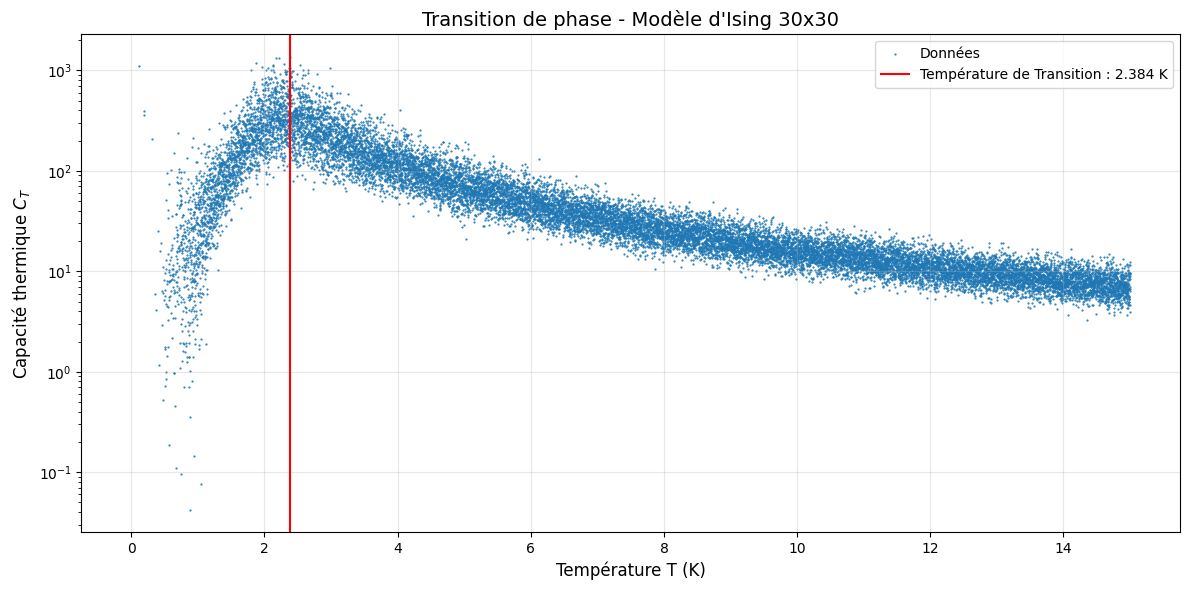

In [33]:
show_transition('3-config.h5', 'fer')
show_transition('10-config.h5', 'fer')
show_transition('30-config.h5', 'fer')

# Etude de la sensibilité magnétique

In [29]:
def show_sensibility(filename, state, T_c = 0):
    # Charger les données depuis le fichier HDF5
    filename = f'../data/metropolis/{state}/sensibility/' + filename

    with h5py.File(filename, 'r') as f:
        # Charger les métadonnées
        J = f['/metadata'].attrs['J']
        B = f['/metadata'].attrs['B']
        T_start = f['/metadata'].attrs['T_start']
        T_end = f['/metadata'].attrs['T_end']
        nb_inter_T = f['/metadata'].attrs['nb_inter_T']
        nb_metropolis_iteration = f['/metadata'].attrs['nb_metropolis_iteration']
        n = f['/metadata'].attrs['n']
        
        # Charger les données C_T
        C_T = f['/C_T'][:]

    # Créer le vecteur de températures
    temperatures = np.linspace(T_start, T_end, nb_inter_T)

    print(f"Données chargées:")
    print(f"  Grille: {n}x{n}")
    if J != 0 or B != 0:
        print(f"  J = {J}, B = {B}")
    print(f"  Températures: {T_start} à {T_end}")
    print(f"  Itérations Metropolis: {nb_metropolis_iteration}")
    print(f"  Nombre de points $\\chi$: {len(C_T)}")

    # Trouver la température de transition (maximum de C_T) pour T > 0.25K
    # Calculer l'index de départ correspondant à T = 0.25
    T_min = 0.25
    start_idx = int((T_min - T_start) / (T_end - T_start) * nb_inter_T)
    start_idx = max(0, start_idx)  # S'assurer que l'index est >= 0
    
    # Trouver le max dans le sous-tableau et ajouter l'offset
    max_idx = start_idx + np.argmax(C_T[start_idx:])
    T_transition = temperatures[max_idx]
    C_T_max = C_T[max_idx]

    print(f"\nTempérature de transition: T_c ≈ {T_transition:.4f} K")
    print(f"Valeur maximale de $\\chi$: {C_T_max:.4e}")

    # Tracer C_T en fonction de la température
    fig, ax = plt.subplots(figsize=(12, 6))

    ax.scatter(temperatures, C_T, s=0.3, label='Données')
    ax.set_xlabel('Température T (K)', fontsize=12)
    ax.set_ylabel(r'Sensibilité Magnétique $\chi$', fontsize=12)
    ax.set_title(f'Sensibilité Magnétique $\\chi$ - Modèle d\'Ising {n}x{n}', fontsize=14)
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')


    # Tracer la temperature de transition
    if T_c != 0:
        T_transition = T_c
    ax.axvline(T_transition, color='red', label=f'Température de Transition : {T_transition:.3f} K')

    plt.tight_layout()
    plt.legend()
    plt.savefig(f'../figures/metropolis/{state}/transition/{n}.png')
    plt.show()

Données chargées:
  Grille: 3x3
  J = 1.0, B = 0.0
  Températures: 0.001 à 15.0
  Itérations Metropolis: 50000
  Nombre de points $\chi$: 20000

Température de transition: T_c ≈ 0.9617 K
Valeur maximale de $\chi$: 8.1589e+01


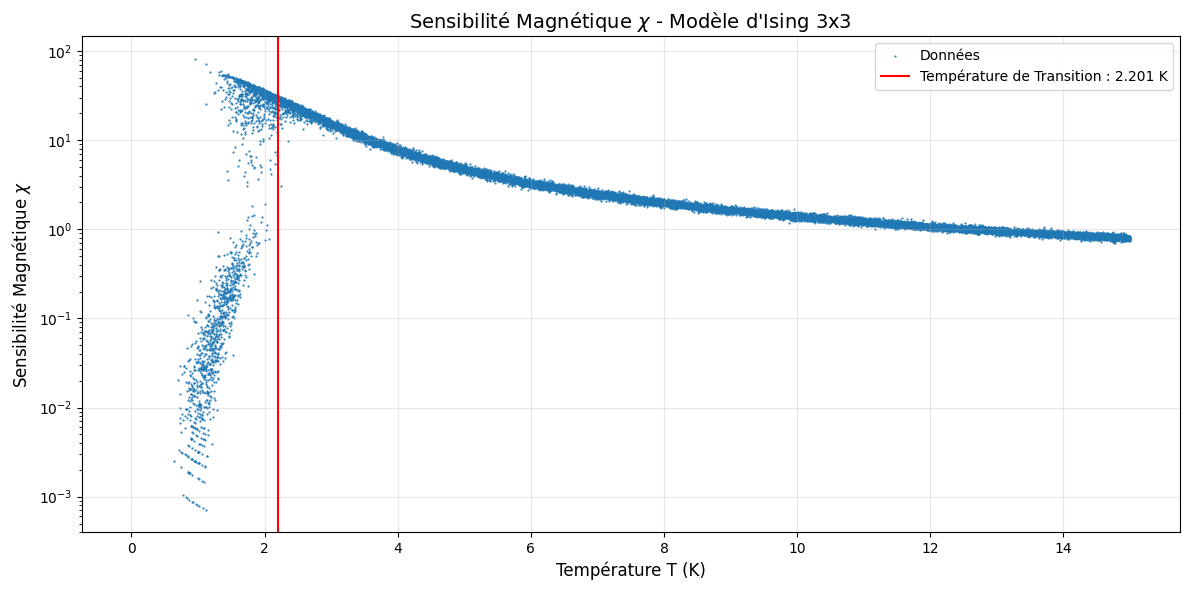

Données chargées:
  Grille: 10x10
  J = 1.0, B = 0.0
  Températures: 0.001 à 15.0
  Itérations Metropolis: 50000
  Nombre de points $\chi$: 20000

Température de transition: T_c ≈ 2.3537 K
Valeur maximale de $\chi$: 1.7988e+03


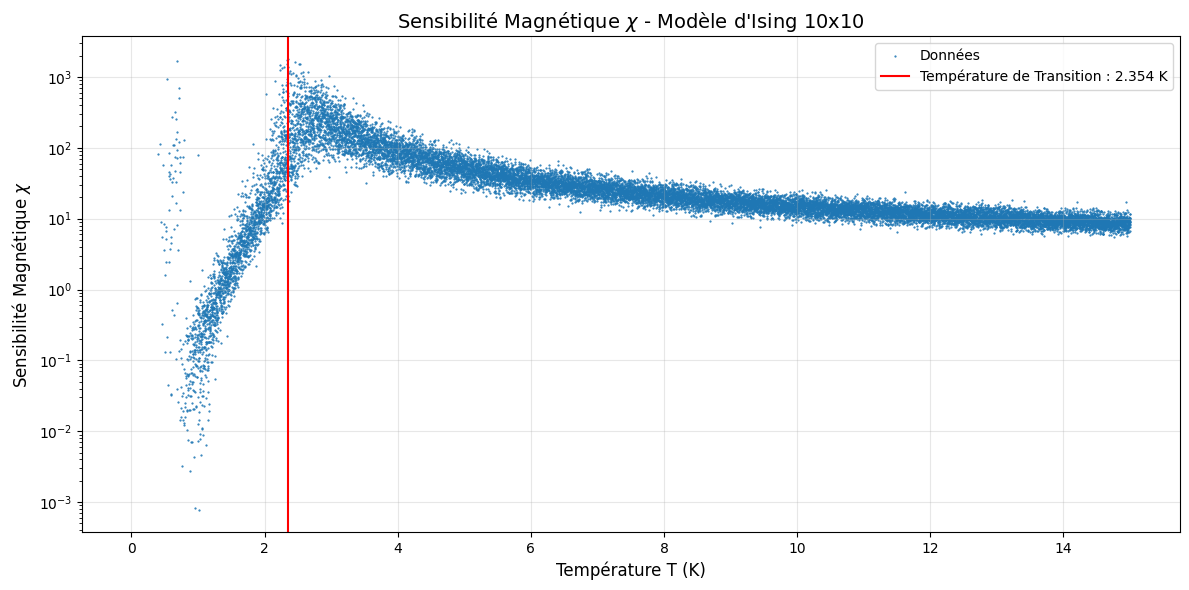

In [31]:
show_sensibility('3-config.h5', 'fer', T_c=2.201)
show_sensibility('10-config.h5', 'fer',)